In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv



Sparsity: 0.0 %

Top Recommendations:

      movieId                                  title
20         21                      Get Shorty (1995)
304       339         While You Were Sleeping (1995)
341       377                           Speed (1994)
1217     1515                         Volcano (1997)
1234     1544  Lost World: Jurassic Park, The (1997)

Improved Evaluation:
RMSE: 0.948
MAE: 0.732


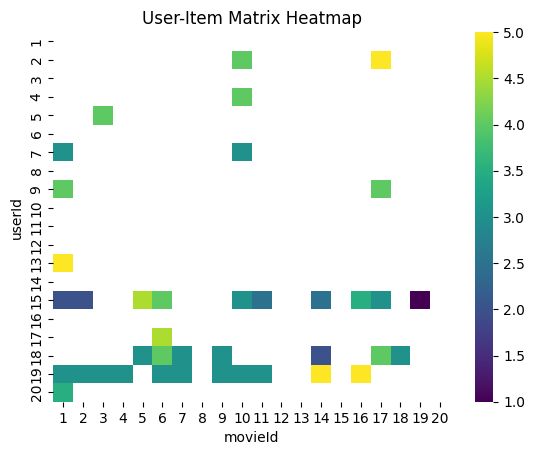

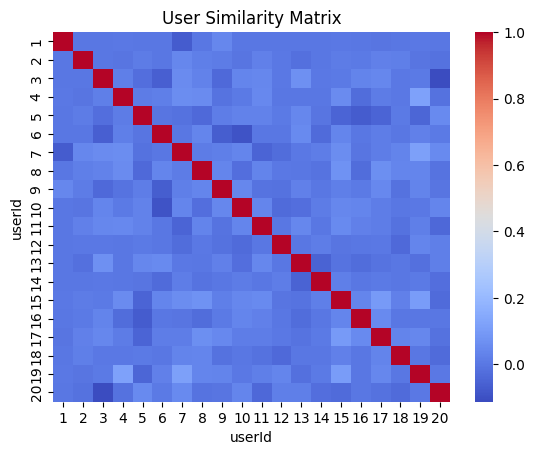

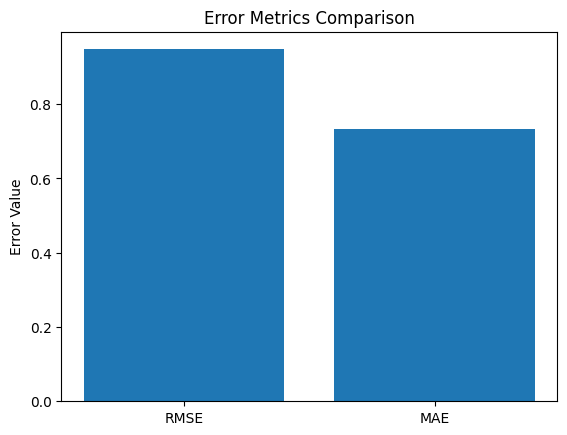

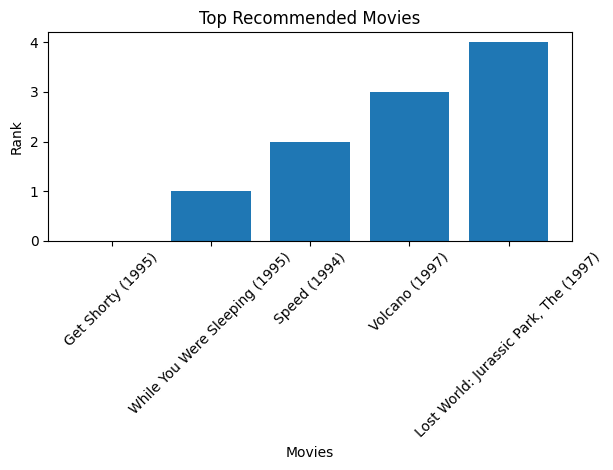

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

user_item = ratings.pivot(index='userId', columns='movieId', values='rating')

sparsity = 1.0 - (np.count_nonzero(user_item) / user_item.size)
print("\nSparsity:", round(sparsity * 100, 2), "%")

user_mean = user_item.mean(axis=1)
user_item_centered = user_item.sub(user_mean, axis=0)
user_item_filled = user_item_centered.fillna(0)

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item.index,
                                  columns=user_item.index)

def get_top_k_users(user_id, k=10):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_id)
    return sim_scores.head(k)

def predict_ratings(user_id, k=10):
    neighbors = get_top_k_users(user_id, k)
    mean_user = user_mean[user_id]
    pred = {}
    for movie in user_item.columns:
        numerator = 0
        denominator = 0
        for neighbor, sim in neighbors.items():
            if not np.isnan(user_item.loc[neighbor, movie]):
                numerator += sim * (user_item.loc[neighbor, movie] - user_mean[neighbor])
                denominator += abs(sim)

        if denominator != 0:
            pred[movie] = mean_user + (numerator / denominator)
        else:
            pred[movie] = mean_user
    return pd.Series(pred)

def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)
    rated_movies = user_item.loc[user_id].dropna().index
    preds = preds.drop(rated_movies)
    top_movies = preds.sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(top_movies.index)][['movieId', 'title']]

user_id = 1

print("\nTop Recommendations:\n")
print(recommend_movies(user_id, 5))

actual = []
predicted = []

for user in user_item.index[:50]:
    preds = predict_ratings(user)
    actual_ratings = user_item.loc[user].dropna()
    for movie in actual_ratings.index:
        actual.append(actual_ratings[movie])
        predicted.append(preds[movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nImproved Evaluation:")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))

plt.figure()
sns.heatmap(user_item.iloc[:20, :20], cmap='viridis')
plt.title("User-Item Matrix Heatmap")
plt.show()

plt.figure()
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("User Similarity Matrix")
plt.show()

plt.figure()
metrics = ['RMSE', 'MAE']
values = [rmse, mae]
plt.bar(metrics, values)
plt.title("Error Metrics Comparison")
plt.ylabel("Error Value")
plt.show()

recommended = recommend_movies(user_id, 5)

plt.figure()
plt.bar(recommended['title'], range(len(recommended)))
plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.xlabel("Movies")
plt.ylabel("Rank")
plt.tight_layout()
plt.show()